# Practical Lab 1: Streaming Data for Predictive Maintenance with Linear Regression-Based Alerts

**Name / Student ID:** Sultan Atanda (9114837)

Extension of the Data Streaming Workshop. The robot current readings are stored in Neon PostgreSQL, a univariate linear regression (time to current) is trained for each of the eight axes straight from the database, the residuals are used to discover the alert and error thresholds, and a synthetic test stream is replayed through the database while an alert module watches it.

Pipeline: `robot_data.csv` -> Neon `lab1_training` -> regression per axis -> residual analysis -> thresholds (MinC, MaxC, T) -> synthetic test data -> Neon `lab1_stream` -> alert detector -> `lab1_alert_events` + `data/alert_log.csv` -> dashboard with month, day and hour filters.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from src.database_service import DatabaseService, AXES
from src.regression_models import AxisRegression
from src.analysis import ResidualAnalyzer
from src.synthetic_data import SyntheticDataGenerator
from src.alerts import AlertDetector, EventLog
from src.streaming_simulator import StreamingSimulator
from src.dashboard import RobotDashboard

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 20)

## 2. Database integration

`DatabaseService` wraps every Neon operation. Three tables are used: `lab1_training` (training readings), `lab1_stream` (the synthetic test stream that is replayed) and `lab1_alert_events` (the alert and error log). The connection string is read from `DATABASE_URL` in `.env`.

In [2]:
db = DatabaseService()
db.test_connection()

db.create_table("lab1_training")
db.create_table("lab1_stream")
db.create_events_table()

db.load_csv("data/robot_data.csv", "lab1_training")
print(db.count_records("lab1_training"), "training rows in Neon")

Database connected successfully.
PostgreSQL 18.6 (4e955f5) on aarch64-unknown-linux-gnu, compiled by gcc (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0, 64-bit
lab1_training table is ready.
lab1_stream table is ready.
lab1_alert_events table is ready.
0 of 39672 rows from data/robot_data.csv inserted into lab1_training.
39672 training rows in Neon


## 3. Pull the training data from the database

The regression models are trained on what comes back from Neon, not on the CSV.

In [3]:
train = db.get_frame("lab1_training")
print(train.shape)
print(train["Timestamp"].min(), "->", train["Timestamp"].max())
display(train[["Timestamp", *AXES]].head())
display(train[AXES].describe().T[["mean", "std", "min", "max"]].round(3))

39672 record(s) retrieved from lab1_training.
(39672, 15)
2022-10-17 12:18:23.660000 -> 2022-10-18 10:44:58.628000


,Timestamp,axis_1,axis_2,axis_3,axis_4,axis_5,axis_6,axis_7,axis_8
0,2022-10-17 12:18:23.660,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2022-10-17 12:18:25.472,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2022-10-17 12:18:27.348,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2022-10-17 12:18:29.222,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2022-10-17 12:18:31.117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,mean,std,min,max
axis_1,0.726,2.162,0.0,23.609
axis_2,3.613,6.880,0.0,51.713
axis_3,2.710,5.112,0.0,41.856
axis_4,0.620,1.575,0.0,15.666
axis_5,0.955,2.100,0.0,20.751
axis_6,0.599,1.815,0.0,20.931
axis_7,0.870,2.167,0.0,8.108
axis_8,0.102,0.423,0.0,5.906


## 4. Machine state: idle versus running

A reading where all eight axes are exactly 0 means the machine was not working. Those readings say nothing about how much current the axes draw when they work, so they are kept out of the regression, the residual statistics, the boxplots and the threshold analysis. Idle readings stay in the stream and in the dashboard, where they simply sit below the regression line and end any run above it.

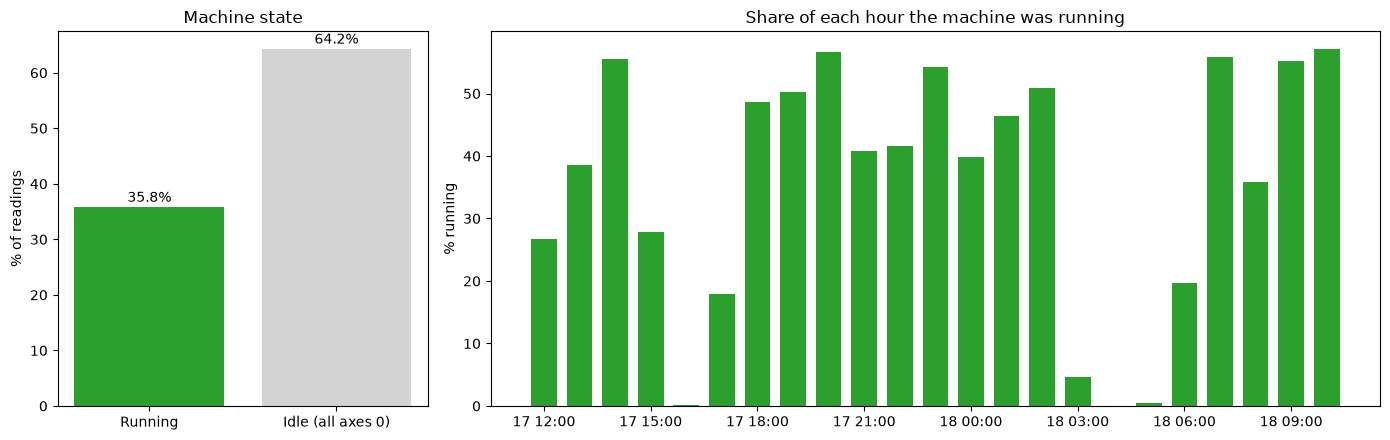

idle readings: 64.2%


In [4]:
ResidualAnalyzer.plot_state_share(train, save="images/results/machine_state.png")
idle_share = 1 - AxisRegression.running_mask(train).mean()
print(f"idle readings: {idle_share:.1%}")

Idle readings are 64.2% of the data. If they were included, the regression line and the residual spread would describe a mix of a stopped and a working machine: the line would sit at about a third of the real working level and the spread would be inflated by the jump between 0 and working values, so the limits would say little about a machine that is actually working.

## 5. Regression models: time to axes 1-8

Time is expressed as seconds since the first training reading. One `LinearRegression` is fitted per axis on the running readings only, and slope, intercept and R2 are recorded. The residual standard deviation (sigma) is also taken from the running readings.

In [5]:
models = AxisRegression().fit(train)
display(models.summary().round(5))

,slope_per_second,slope_per_hour,intercept,r2,resid_std,resid_p99,resid_max,samples
axis,,,,,,,,
Axis #1,-0.0,-0.00263,2.05956,0.00003,3.22906,13.84377,21.56681,14185
Axis #2,0.0,0.01412,9.94530,0.00013,8.17065,31.77522,41.61872,14185
Axis #3,-0.0,-0.01116,7.70693,0.00015,6.01352,22.29961,34.35966,14185
Axis #4,0.0,0.00255,1.70570,0.00006,2.23681,10.05419,13.94649,14185
Axis #5,-0.0,-0.00112,2.68229,0.00001,2.78516,10.73516,18.08039,14185
Axis #6,0.0,0.00342,1.63756,0.00007,2.72248,12.35596,19.23302,14185
Axis #7,0.0,0.00365,2.39214,0.00006,3.05374,5.69605,5.71608,14185
Axis #8,0.0,0.00062,0.27878,0.00004,0.66938,3.66256,5.61837,14185


,readings,running,idle,running_%,idle_%
training data,39672.0,14185.0,25487.0,35.8,64.2


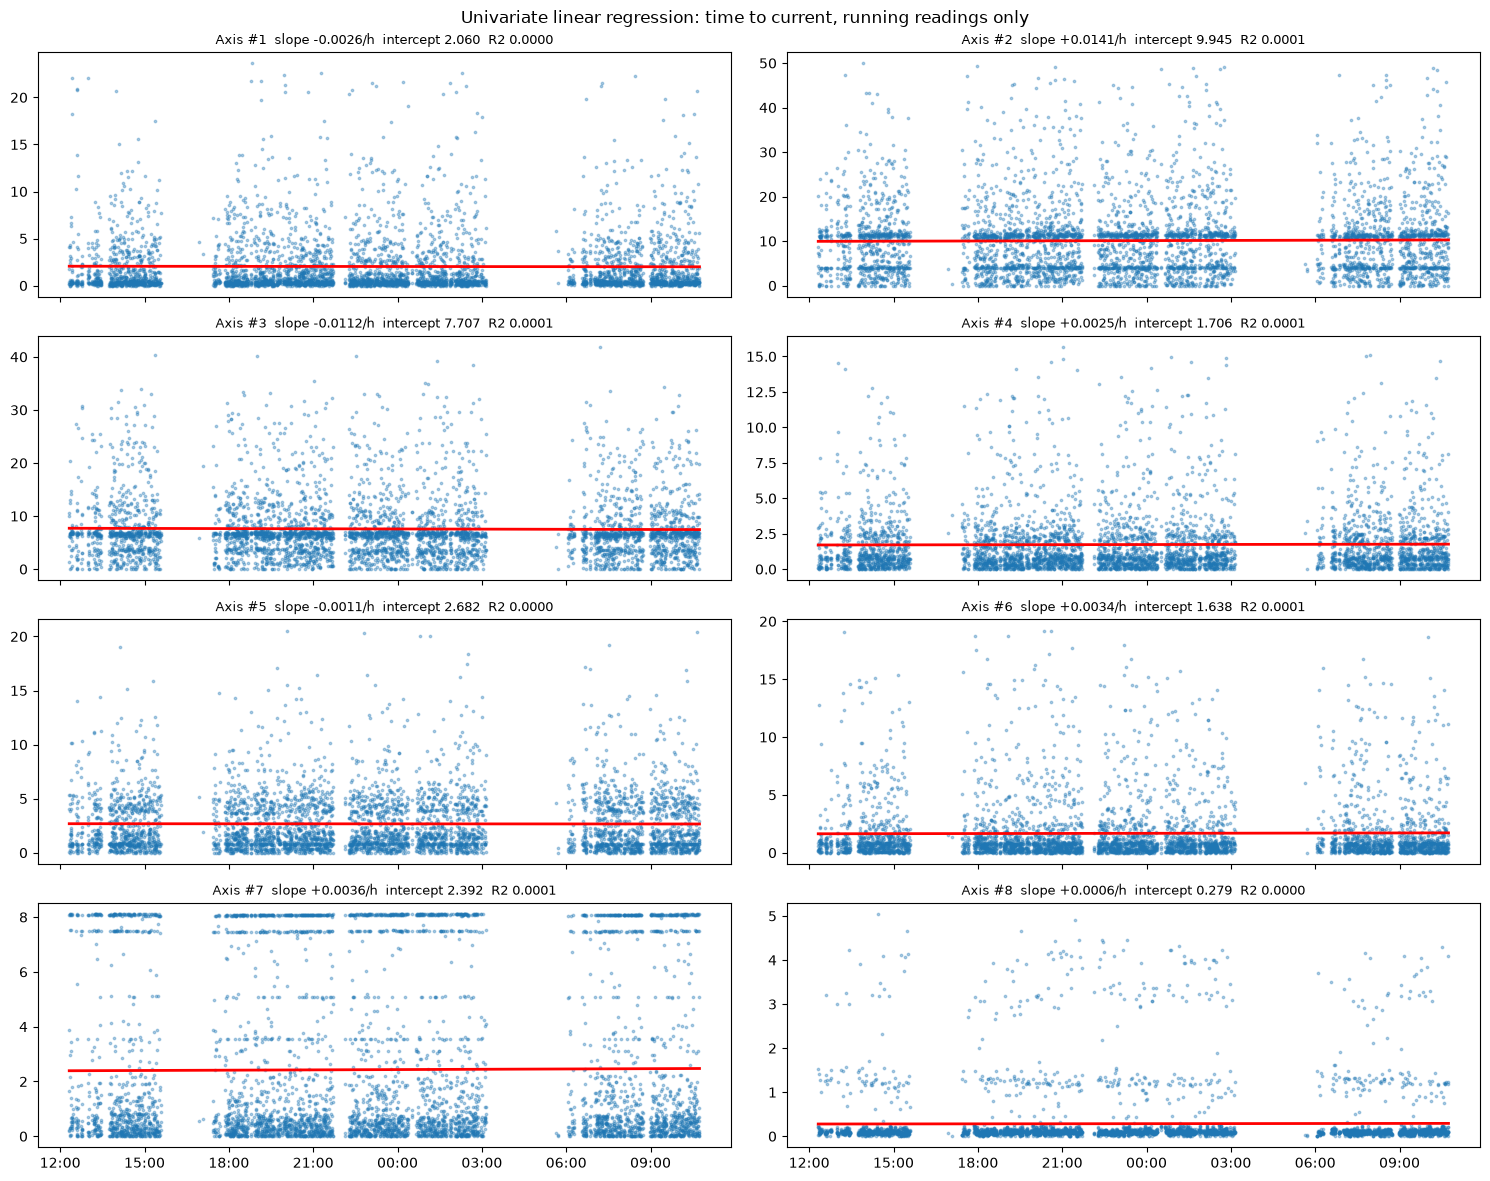

In [6]:
analyzer = ResidualAnalyzer(models, train)
display(analyzer.state_summary().to_frame("training data").T)
analyzer.plot_regressions(save="images/results/regression_fits.png")

The slopes are close to zero (a hundredth of a unit per hour at most) and R2 is below 0.0002 on every axis. Over the recorded day the working level of the robot does not drift, so the regression line is the expected working level of each axis. That is the useful part for maintenance: a slow upward drift in a later window would show up as a positive residual.

## 6. Residual analysis

Residual = observed current minus the regression prediction, on the running readings. Only the positive side matters for this task (current above the line).

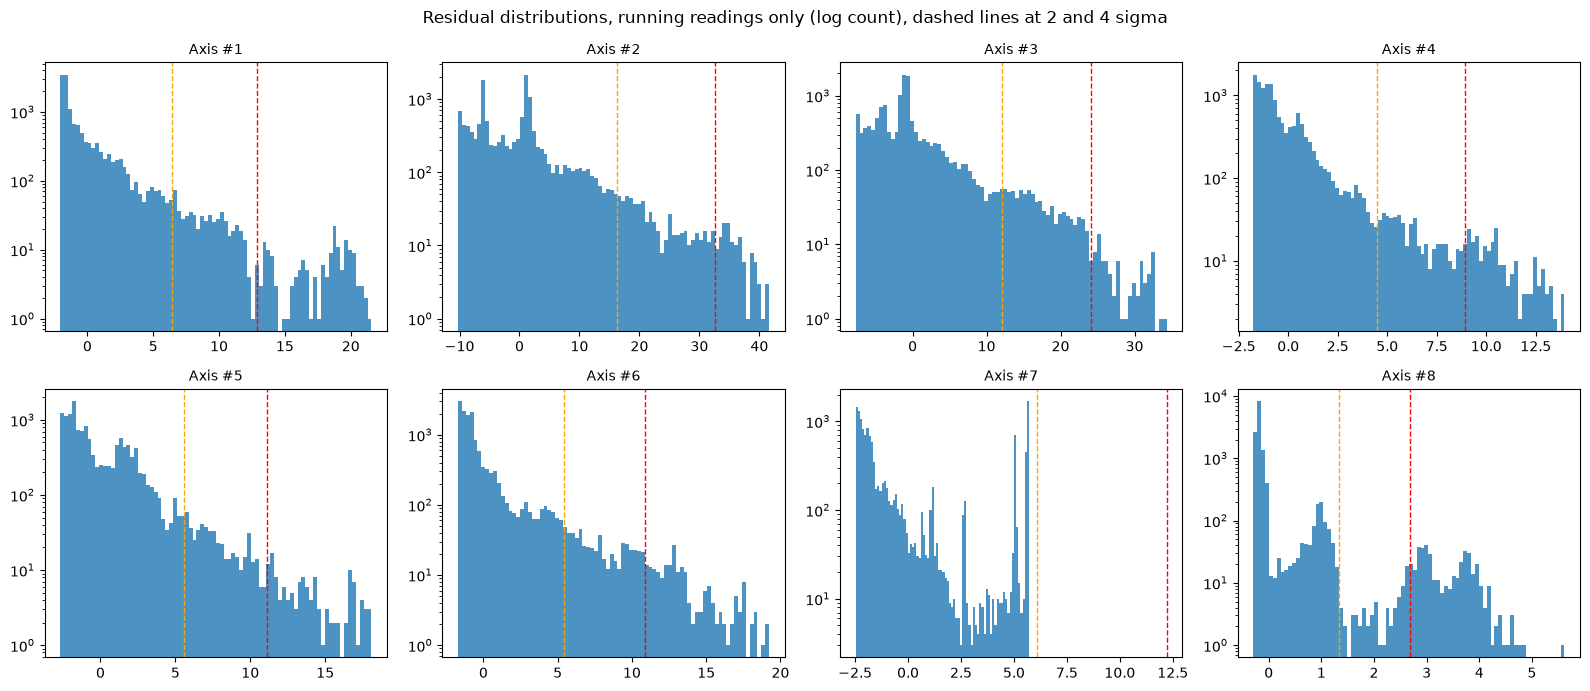

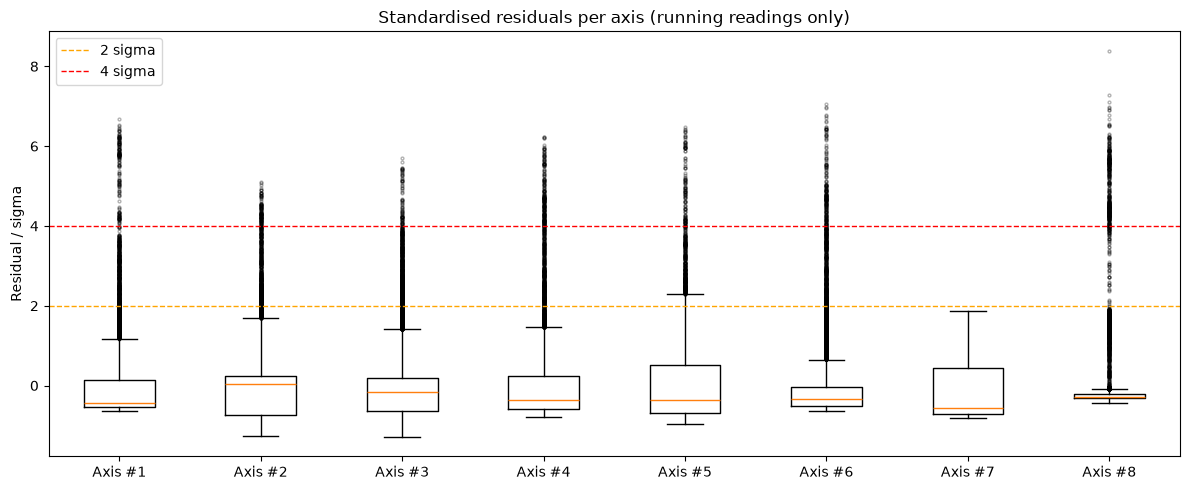

In [7]:
analyzer.plot_residual_histograms(save="images/results/residual_histograms.png")
analyzer.plot_residual_boxplots(save="images/results/residual_boxplots.png")

In [8]:
print("Running readings above the regression line by at least k sigma (out of", int(analyzer.mask.sum()), ")")
display(analyzer.outlier_table())
print("Same, as % of running readings")
display(analyzer.outlier_table(share=True).round(1))

Running readings above the regression line by at least k sigma (out of 14185 )


,>= 1 sigma,>= 2 sigma,>= 3 sigma,>= 4 sigma,>= 5 sigma
Axis #1,1478,738,363,169,121
Axis #2,1779,702,304,123,3
Axis #3,1715,870,339,81,26
Axis #4,1404,725,392,241,70
Axis #5,1598,643,283,129,55
Axis #6,1569,761,420,209,70
Axis #7,3127,0,0,0,0
Axis #8,1257,477,455,401,197


Same, as % of running readings


,>= 1 sigma,>= 2 sigma,>= 3 sigma,>= 4 sigma,>= 5 sigma
Axis #1,10.4,5.2,2.6,1.2,0.9
Axis #2,12.5,4.9,2.1,0.9,0.0
Axis #3,12.1,6.1,2.4,0.6,0.2
Axis #4,9.9,5.1,2.8,1.7,0.5
Axis #5,11.3,4.5,2.0,0.9,0.4
Axis #6,11.1,5.4,3.0,1.5,0.5
Axis #7,22.0,0.0,0.0,0.0,0.0
Axis #8,8.9,3.4,3.2,2.8,1.4


Every axis has a long right tail: 3% to 6% of the running readings sit at least 2 sigma above the line and 0.6% to 2.8% at least 4 sigma above it. Axis #7 is the exception: it saturates at 8.1, which is below its line plus 2 sigma, so it never reaches those levels in normal operation. The tail readings are normal working peaks (the axis draws more current while it moves), so a rule on single readings would flood the operators with false alarms. The **time condition T** is what separates a working peak from a real problem, and the next section measures how long those normal peaks last.

## 7. Discovering MinC, MaxC and T

For each axis and each candidate level (k sigma above the line, sigma being the residual standard deviation of that axis while running) the code measures every continuous run above the level and keeps the longest one. Idle readings are below the line, so they end a run. Limits are expressed in sigma because the eight axes have very different scales (Axis #2 peaks at 51, Axis #8 at 6).

In [9]:
print("Longest continuous run above the line, in seconds (training data)")
longest = analyzer.longest_runs((1, 1.5, 2, 3, 4))
display(longest)
print("Overall longest run per level:")
display(longest.max().round(1).to_frame("seconds").T)

Longest continuous run above the line, in seconds (training data)


,1 sigma,1.5 sigma,2 sigma,3 sigma,4 sigma
Axis #1,7.816,5.547,5.547,0.000,0.0
Axis #2,6.200,6.058,6.058,0.000,0.0
Axis #3,7.672,7.672,5.734,1.954,0.0
Axis #4,6.539,6.539,0.000,0.000,0.0
Axis #5,8.015,6.234,2.015,1.976,0.0
Axis #6,5.947,5.680,5.680,1.984,0.0
Axis #7,11.509,11.509,0.000,0.000,0.0
Axis #8,2.140,2.140,0.000,0.000,0.0


Overall longest run per level:


,1 sigma,1.5 sigma,2 sigma,3 sigma,4 sigma
seconds,11.5,11.5,6.1,2.0,0.0


Number of sustained events the healthy training data would raise, for every level and duration


,T=10s,T=20s,T=30s,T=45s,T=60s
1 sigma,2,0,0,0,0
1.5 sigma,2,0,0,0,0
2 sigma,0,0,0,0,0
3 sigma,0,0,0,0,0
4 sigma,0,0,0,0,0


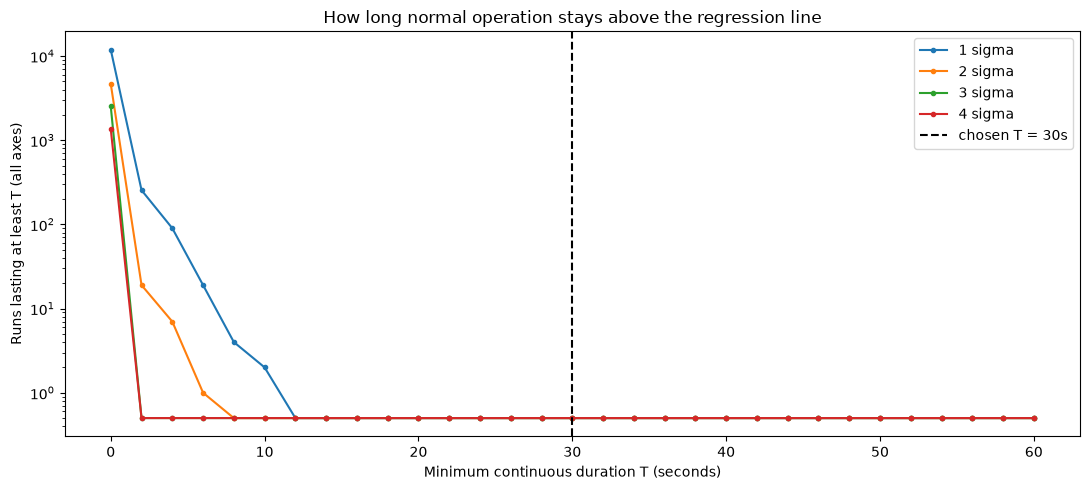

In [10]:
print("Number of sustained events the healthy training data would raise, for every level and duration")
display(analyzer.event_grid((1, 1.5, 2, 3, 4), (10, 20, 30, 45, 60)))
analyzer.plot_run_lengths(ks=(1, 2, 3, 4), chosen=30, save="images/results/run_lengths.png")

### Chosen thresholds

| Parameter | Value | Evidence |
|---|---|---|
| **T** | **30 s** | The longest normal run above the line is 11.5 s at 1 sigma (Axis #7) and 6.1 s at 2 sigma. Anything shorter than that is a normal working cycle. 30 s is 2.6x the longest run at the loosest level and 4.9x the longest at MinC. In the event grid the healthy training data raises no event at T = 20 s or more for any level, and only 2 (at 1 and 1.5 sigma) if T is 10 s. |
| **MinC** | **2 sigma** above the line (per axis) | 1 sigma is inside ordinary operation (9% to 22% of the running readings are above it per axis) and has the longest healthy runs. At 2 sigma only about 5% of the running readings qualify and the longest healthy run drops to 6.1 s, while a real fault such as a friction increase still sits well beyond it. |
| **MaxC** | **4 sigma** above the line (per axis) | Twice the alert level. About 1% of the running readings reach it (0.6% to 2.8% per axis) and in healthy data no two consecutive readings do on any axis, so a condition lasting 30 s is far outside anything the robot did in normal operation. Axis #7 saturates at about 8.1, below its own line plus MinC, so an alert or error there means the axis exceeded its usual ceiling. |

Predictive maintenance reading: an **Alert** means the axis has been drawing clearly more current than its regression baseline for half a minute, which is worth an inspection at the next planned stop. An **Error** means the current is at least four sigma above baseline for half a minute, which is the kind of load seen before a torque tube or gearbox failure, so the robot should be stopped and checked. Because the Error level implies the Alert level, an error always comes with an alert on the same axis, and a slow ramp-up produces the alert first.

In [11]:
MIN_SIGMA = 2.0
MAX_SIGMA = 4.0
DURATION = 30.0

detector = AlertDetector(models, min_sigma=MIN_SIGMA, max_sigma=MAX_SIGMA, duration=DURATION)
limits = pd.DataFrame({
    "regression sigma": {models.label(c): models.sigma[c] for c in AXES},
    "MinC (units above line)": {models.label(c): detector.min_c[c] for c in AXES},
    "MaxC (units above line)": {models.label(c): detector.max_c[c] for c in AXES},
})
display(limits.round(3))
print(f"T = {DURATION:g} s")

,regression sigma,MinC (units above line),MaxC (units above line)
Axis #1,3.229,6.458,12.916
Axis #2,8.171,16.341,32.683
Axis #3,6.014,12.027,24.054
Axis #4,2.237,4.474,8.947
Axis #5,2.785,5.570,11.141
Axis #6,2.722,5.445,10.890
Axis #7,3.054,6.107,12.215
Axis #8,0.669,1.339,2.678


T = 30 s


## 8. Synthetic test data

The generator receives the training data pulled from the database and builds a 48 hour test stream that starts on 2022-10-31 12:00 UTC, so it crosses a month and two day boundaries (used by the dashboard filters).

1. Blocks of about an hour are resampled from the training data with 3% multiplicative jitter on non-zero readings. Blocks are copied whole, so the idle and running pattern of the machine is kept.
2. **Standardisation:** each axis is converted to z-scores and mapped back with the training mean and standard deviation.
3. **Min-max normalisation:** the result is normalised with the training minimum and maximum, clipped to [0, 1] and mapped back, so no synthetic reading leaves the training range.
4. Faults are injected on top (after the scaling) and recorded as ground truth. A fault of k sigma lifts the axis to the regression line plus k sigma of that axis, so its size is measured the same way as the thresholds. There are steps and one ramp on single axes, one multi-axis overload, one blip shorter than T and one deviation smaller than MinC.

In [12]:
generator = SyntheticDataGenerator(train, seed=8010)
test = generator.generate("2022-10-31 12:00:00", hours=48, models=models)

test.to_csv("data/synthetic_test.csv", index=False)
generator.faults.to_csv("data/synthetic_faults.csv", index=False)

print(test.shape)
shares = generator.idle_share(test)
print(f"idle share: training {shares['train']:.1%}, test {shares['test']:.1%}")
print("Running readings only:")
display(generator.compare(test).round(3))
display(generator.faults)

(91258, 10)
idle share: training 64.2%, test 61.5%
Running readings only:


,train_mean,test_mean,train_std,test_std,train_max,test_max
Axis #1,2.030,1.934,3.229,3.140,23.609,23.609
Axis #2,10.106,9.701,8.171,8.480,51.713,77.617
Axis #3,7.580,7.353,6.014,6.308,41.856,53.688
Axis #4,1.735,1.668,2.237,2.252,15.666,25.290
Axis #5,2.670,2.524,2.785,2.747,20.751,21.470
Axis #6,1.676,1.796,2.723,3.030,20.931,25.471
Axis #7,2.434,2.317,3.054,2.996,8.108,11.655
Axis #8,0.286,0.270,0.669,0.647,5.906,5.906


,axis,start,end,length_s,sigma,kind
0,Axis #2,2022-10-31 17:00:00.535,2022-10-31 17:01:29.348,88.8,3.0,step
1,Axis #5,2022-10-31 21:00:01.248,2022-10-31 21:00:18.291,17.0,5.0,step
2,Axis #3,2022-11-01 08:00:00.554,2022-11-01 08:03:59.869,239.3,5.0,step
3,Axis #7,2022-11-01 15:00:01.372,2022-11-01 15:01:58.549,117.2,2.6,step
4,Axis #6,2022-11-01 21:00:01.587,2022-11-01 21:24:59.134,1497.5,6.0,ramp
5,Axis #1,2022-11-02 04:00:01.586,2022-11-02 04:04:58.197,296.6,1.0,step
6,Axis #2,2022-11-02 08:00:00.512,2022-11-02 08:02:28.203,147.7,4.5,step
7,Axis #3,2022-11-02 08:00:00.512,2022-11-02 08:02:28.203,147.7,4.5,step
8,Axis #4,2022-11-02 08:00:00.512,2022-11-02 08:02:28.203,147.7,4.5,step


## 9. Streaming simulation and alert detection

`StreamingSimulator` replays the synthetic CSV in time order. Each batch is inserted into Neon (`lab1_stream`), passed to the `AlertDetector`, which keeps a running state per axis and level, and the live dashboard is refreshed from the last rows in the database. Events are written to `lab1_alert_events` and `data/alert_log.csv` as soon as a run ends. Batches of 500 readings with a short pause stand in for the real 2 second cadence, otherwise two days of data would take two days to replay.

In [13]:
db.clear_table("lab1_stream")

log = EventLog("data/alert_log.csv", db)
log.reset()

detector = AlertDetector(models, MIN_SIGMA, MAX_SIGMA, DURATION)
dashboard = RobotDashboard(db, models, detector, log, table="lab1_stream")
ss = StreamingSimulator("data/synthetic_test.csv", db, table="lab1_stream")

first = ss.nextDataPoint()
display(first.to_frame().T)
ss.current_index = 0

lab1_stream cleared.


,Trait,Axis #1,Axis #2,Axis #3,Axis #4,Axis #5,Axis #6,Axis #7,Axis #8,Time
0,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022-10-31T12:00:01.860Z


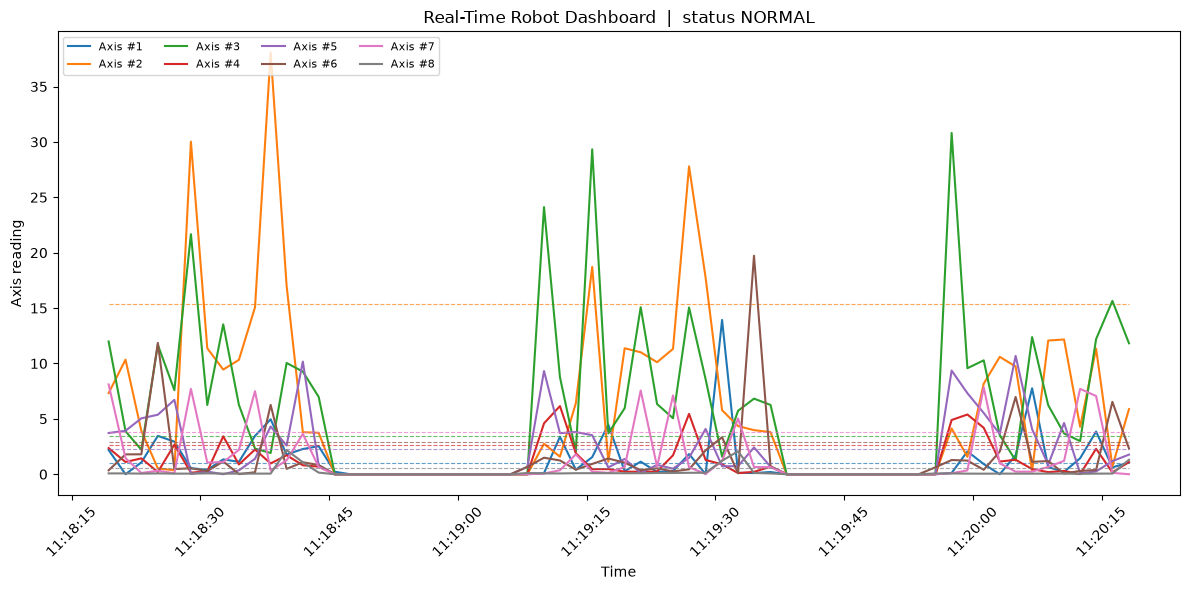

Streaming stopped. 91258 readings sent, 12 events logged.


In [14]:
events = ss.start_stream(
    dashboard=dashboard,
    detector=detector,
    log=log,
    batch_size=500,
    delay=0.3,
    refresh_every=15,
)

## 10. Results: alerts and errors

In [15]:
events = log.read()
display(events)
print(events["level"].value_counts().to_string())
print("rows in lab1_alert_events:", len(db.get_events()))

,level,axis,start,end,duration_s,peak_deviation,mean_deviation,limit_c,min_duration_s
0,ALERT,Axis #2,2022-10-31 17:00:00.535,2022-10-31 17:01:29.348,88.8,24.512,24.512,16.341,30.0
1,ALERT,Axis #3,2022-11-01 08:00:00.554,2022-11-01 08:04:01.736,241.2,47.411,30.759,12.027,30.0
2,ERROR,Axis #3,2022-11-01 08:00:00.554,2022-11-01 08:03:59.869,239.3,47.411,30.836,24.054,30.0
3,ALERT,Axis #7,2022-11-01 15:00:01.372,2022-11-01 15:01:58.549,117.2,7.940,7.939,6.107,30.0
4,ALERT,Axis #6,2022-11-01 21:10:52.596,2022-11-01 21:24:59.134,846.5,22.570,11.207,5.445,30.0
5,ERROR,Axis #6,2022-11-01 21:17:57.072,2022-11-01 21:24:59.134,422.1,19.556,13.695,10.890,30.0
6,ALERT,Axis #2,2022-11-02 08:00:00.512,2022-11-02 08:02:28.203,147.7,62.309,41.309,16.341,30.0
7,ERROR,Axis #2,2022-11-02 08:00:00.512,2022-11-02 08:02:28.203,147.7,62.309,41.309,32.683,30.0
8,ALERT,Axis #3,2022-11-02 08:00:00.512,2022-11-02 08:02:28.203,147.7,50.219,31.086,12.027,30.0
9,ERROR,Axis #3,2022-11-02 08:00:00.512,2022-11-02 08:02:28.203,147.7,50.219,31.086,24.054,30.0


level
ALERT    7
ERROR    5
rows in lab1_alert_events: 12


Every injected fault is compared with what the detector reported. `expected` is what the rules say should happen for that fault (its size and length against MinC, MaxC and T), `detected` is what was logged, and `delay_s` is the time between the start of the fault and the start of the first logged event. Any event that does not overlap an injected fault is a false alarm.

In [16]:
faults = pd.read_csv("data/synthetic_faults.csv", parse_dates=["start", "end"])
check, false_alarms = detector.evaluate(events, faults)
display(check)
print("false alarms:", len(false_alarms))

,axis,injected_at,length_s,sigma,kind,expected,detected,delay_s
0,Axis #2,2022-10-31 17:00:00.535,88.8,3.0,step,ALERT,ALERT,0.000
1,Axis #5,2022-10-31 21:00:01.248,17.0,5.0,step,NONE,NONE,NaN
2,Axis #3,2022-11-01 08:00:00.554,239.3,5.0,step,ERROR,ALERT+ERROR,0.000
3,Axis #7,2022-11-01 15:00:01.372,117.2,2.6,step,ALERT,ALERT,0.000
4,Axis #6,2022-11-01 21:00:01.587,1497.5,6.0,ramp,ERROR,ALERT+ERROR,651.009
5,Axis #1,2022-11-02 04:00:01.586,296.6,1.0,step,NONE,NONE,NaN
6,Axis #2,2022-11-02 08:00:00.512,147.7,4.5,step,ERROR,ALERT+ERROR,0.000
7,Axis #3,2022-11-02 08:00:00.512,147.7,4.5,step,ERROR,ALERT+ERROR,0.000
8,Axis #4,2022-11-02 08:00:00.512,147.7,4.5,step,ERROR,ALERT+ERROR,0.000


false alarms: 0


Sensitivity of the outcome to the thresholds, replaying the same test stream through detectors with other settings. A fault counts as real when it is at least 2 sigma high and at least 30 s long (7 of the 9 injected faults). Because the baseline is fitted on running readings, no setting produces false alarms on this healthy stream, so the comparison is about what each setting finds and when.

In [17]:
readings = StreamingSimulator.as_readings(test)
real = faults[(faults["sigma"] >= 2) & (faults["length_s"] >= 30)]
rows = []
for low, high, seconds in [(1, 3, 10), (1, 3, 30), (2, 4, 10), (2, 4, 30), (2, 4, 60), (2, 4, 120), (3, 5, 30), (2, 6, 30)]:
    trial = AlertDetector(models, low, high, seconds)
    found = trial.detect(readings)
    hits, extra = trial.evaluate(found, real)
    _, stray = trial.evaluate(found, faults)
    rows.append({
        "MinC": f"{low} sigma", "MaxC": f"{high} sigma", "T": f"{seconds} s",
        "alerts": int((found["level"] == "ALERT").sum()),
        "errors": int((found["level"] == "ERROR").sum()),
        "false alarms": len(stray),
        "real faults found": f"{int((hits['detected'] != 'NONE').sum())} / {len(real)}",
    })
display(pd.DataFrame(rows))

,MinC,MaxC,T,alerts,errors,false alarms,real faults found
0,1 sigma,3 sigma,10 s,9,7,0,7 / 7
1,1 sigma,3 sigma,30 s,8,6,0,7 / 7
2,2 sigma,4 sigma,10 s,8,6,0,7 / 7
3,2 sigma,4 sigma,30 s,7,5,0,7 / 7
4,2 sigma,4 sigma,60 s,7,5,0,7 / 7
5,2 sigma,4 sigma,120 s,5,5,0,5 / 7
6,3 sigma,5 sigma,30 s,6,2,0,6 / 7
7,2 sigma,6 sigma,30 s,7,0,0,7 / 7


The table shows why the chosen setting is the compromise. A T of 120 s misses the two faults that last less than two minutes. Raising the levels to 3 and 5 sigma misses the 2.6 sigma fault, and a MaxC of 6 sigma never raises an error. Lower settings such as 1 sigma or T = 10 s also find every fault on this stream, but they sit at the edge of normal operation: 1 sigma is where the healthy training data has its longest runs and the only healthy events (2 at T = 10 s), so they are less safe on a real robot than 2 sigma and 30 s, which keep a margin of several times over anything healthy.

## 11. Dashboard with month, day and hour filters

`RobotDashboard.interactive()` builds four drop-downs (month, day, hour, axis). The lists narrow with the selection: picking a month only offers the days that have data in that month, and picking a day only offers its hours. Every panel shows the current, the regression line, the lines at MinC and MaxC above it, and each alert or error as a shaded span with a marker annotated with its duration in seconds. The title shows the share of readings in the window that were running. Long windows are reduced to at most 2,500 points by keeping the peak of each bin so short spikes stay visible.

In [ ]:
dashboard.interactive()

91258 record(s) retrieved from lab1_stream.


The same filters are available as a function call, which also lets the views be saved as images for the report.

91258 record(s) retrieved from lab1_stream.


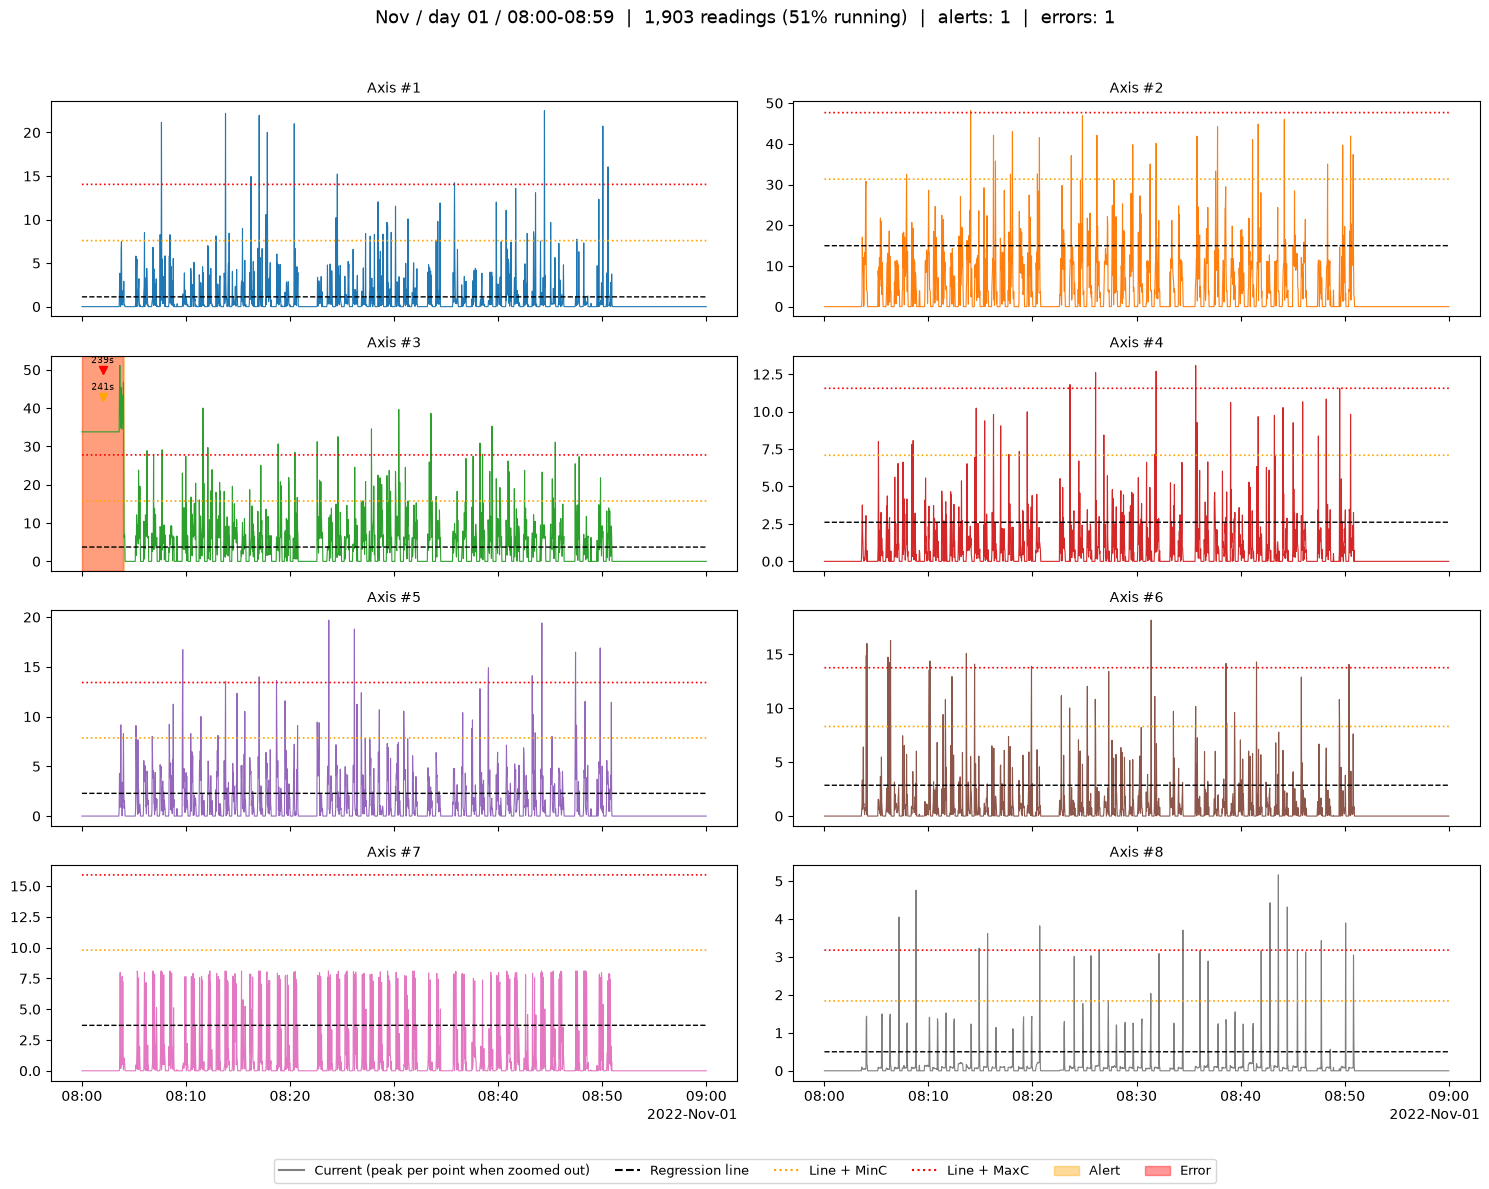

,level,axis,start,end,duration_s,peak_deviation
0,ALERT,Axis #3,2022-11-01 08:00:00.554,2022-11-01 08:04:01.736,241.2,47.411
1,ERROR,Axis #3,2022-11-01 08:00:00.554,2022-11-01 08:03:59.869,239.3,47.411


In [19]:
dashboard.load()
dashboard.show(month=11, day=1, hour=8)
dashboard.save_view("images/results/dashboard_hour.png", month=11, day=1, hour=8)

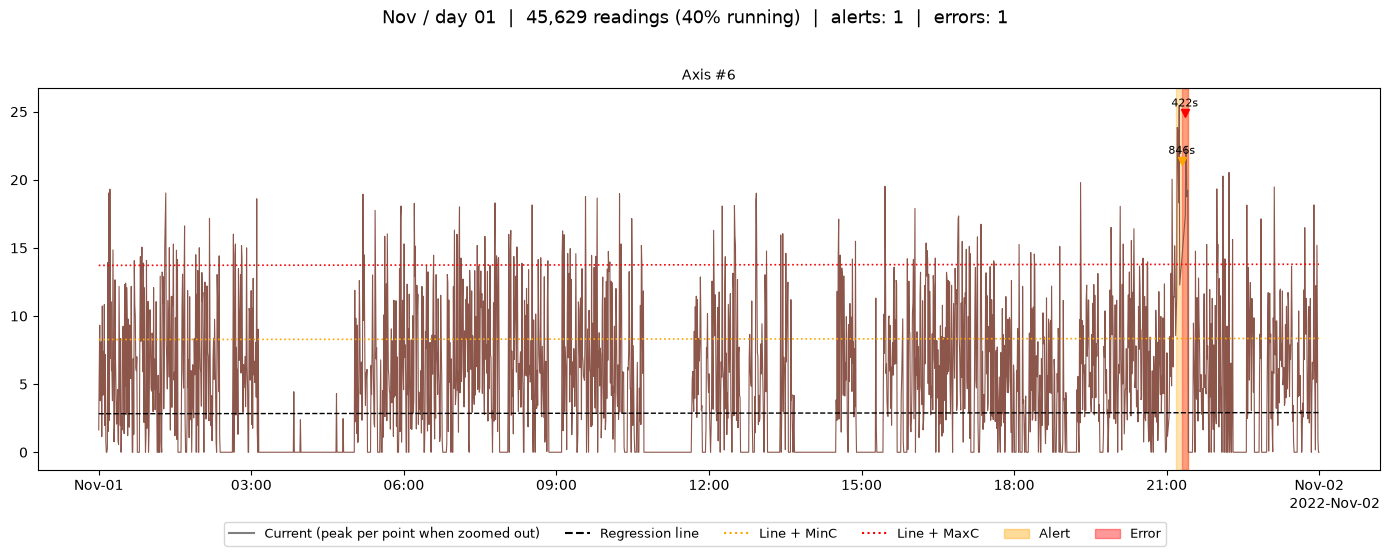

,level,axis,start,end,duration_s,peak_deviation
0,ALERT,Axis #6,2022-11-01 21:10:52.596,2022-11-01 21:24:59.134,846.5,22.570
1,ERROR,Axis #6,2022-11-01 21:17:57.072,2022-11-01 21:24:59.134,422.1,19.556


In [20]:
dashboard.show(month=11, day=1, axis=6)
dashboard.save_view("images/results/dashboard_day_axis6.png", month=11, day=1, axis=6)
dashboard.save_view("images/results/dashboard_month.png", month=11)

## 12. Interpretation and limits

- The regression slopes are almost flat, so the baseline is the average working level and the alerts are driven by sustained deviations rather than by trend. The ramp on Axis #6 shows the early warning value: the alert fires about eleven minutes into the ramp, and the error about seven minutes after that.
- Thresholds in sigma units transfer across axes with very different scales. They are estimated from one day of healthy-looking data. If that day already contained a developing fault, the baseline would be too tolerant, so in production the baseline should be refreshed after each verified maintenance.
- The test data is synthetic and the faults are injected, so the detection results measure whether the rules do what they were designed to do, not how well they would predict real failures. Real failure records would be needed to tune T and MaxC against actual downtime.
- Time is the only predictor, and idle readings are removed before fitting. Even among running readings the current swings between the phases of each work cycle, which is why the residual spread is large and the thresholds have to be several sigma wide.